# Dataset visualization

Inspects and analyzes a saved `BeamDataset` (`.pt` file) against the **current** `beam_optimization` configuration (`config/adige.py`): schema/composition, per-parameter and per-stage statistics, distributions, score, a single combined parameter/beam-state correlation matrix, and dataset coverage.

> This notebook is read-only: it only loads an existing dataset file, it does not run TraceWin and does not change anything on disk.

## 0. How this dataset was built

Every row here comes from one real TraceWin simulation, produced by `TraceWinDatasetBuilder`
(`env/dataset/tracewin_dataset_builder.py`):

1. **Sample parameters from a Gaussian centered on the machine defaults.** Independently for each of
   the `N_PARAMS` parameters: `value = default + Normal(0, sensitivity * DATASET_SCALE)`, then clipped
   to that parameter's hardware bounds (`hw_min`/`hw_max`). Parameters are drawn independently (a
   diagonal covariance, no correlation imposed at generation time) -- any correlation you see in
   section 5 is a real physics effect from TraceWin transport, not an artifact of how the samples were
   generated.
2. **Run the real simulator** on the sampled parameters (`simulator.simulate(params)`).
3. **Accept or reject.** A sample is kept if TraceWin returned a real result and either (a) the beam
   was transported successfully, or (b) all particles were lost partway through and TraceWin encoded
   that as a physics failure (the beam state is zeroed from the loss point onward) -- both outcomes are
   informative and kept. Only *technical* failures (simulator crashes, non-physical returns) are
   discarded, and the attempt is silently retried with a fresh draw.
4. **Repeat until `target_samples` accepted rows exist.** Every attempt draws from
   `np.random.default_rng(seed + attempt_index)`, so a whole build -- including which attempts failed --
   is exactly reproducible from one `seed`. Progress is checkpointed to `builder_state.json`, so an
   interrupted build resumes exactly where it left off; changing the sampling configuration (e.g. a
   different `DATASET_SCALE`) is detected and the build refuses to resume, rather than silently mixing
   two distributions in one file.
5. **Split 80/10/10** into train/val/test (shuffled with a fixed seed), saved alongside `dataset_all.pt`.

`DATASET_SCALE` is not an arbitrary width -- `exploration_scale_calculation` calibrates it to hit
roughly an **80% TraceWin success rate**, so the ~20% "all particles lost" rows you will see in
section 4 are intentional boundary-region coverage, not a building error (see also
`visualize_environments.ipynb`, which uses the same `DATASET_SCALE` for the RL environment's own reset
distribution).

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'beam_optimization').is_dir():
    REPO_ROOT = WORKING_DIR
else:
    PROJECT_ROOT = WORKING_DIR
    while PROJECT_ROOT.name != 'beam_optimization' and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent
    REPO_ROOT = PROJECT_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_optimization.config.adige import (
    BEAM_STATE_DIM, BEAM_STATE_FEATURES, DATASET_SCALE, ERROR_SCORE,
    N_OUTPUT_STAGES, N_PARAMS, N_STAGES, PARAMETERS, STAGE_MARKERS,
    default_params, params_to_vec, score_function_metadata, sensitivity_vec,
)
from beam_optimization.config.paths import default_dataset_path
from beam_optimization.env.dataset import BeamDataset


def fmt(value):
    return f'{float(value):.6g}'


def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(str(cell) for cell in row) + ' |' for row in rows)
    return '\n'.join(lines)


def stage_label(index):
    """Match the beam0/marker_X convention used throughout the project."""
    if index == 0:
        return 'beam0'
    return f'marker_{STAGE_MARKERS[index]}'


def plot_grid_hist(data_list, labels, title, bins=60, ncols=6, cell_w=3.0, cell_h=2.1):
    n = len(data_list)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(cell_w * ncols, cell_h * nrows))
    axes = np.atleast_1d(axes).reshape(nrows, ncols).ravel()
    for i, ax in enumerate(axes):
        if i >= n:
            ax.axis('off')
            continue
        values = np.asarray(data_list[i], dtype=float)
        ax.hist(values, bins=bins, alpha=0.85, color='steelblue', edgecolor='black', linewidth=0.3)
        ax.set_title(labels[i], fontsize=7.5)
        ax.tick_params(labelsize=6)
        ax.text(
            0.03, 0.95, f'μ={np.mean(values):.3g}\nσ={np.std(values):.3g}',
            transform=ax.transAxes, va='top', ha='left', fontsize=6,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        )
    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()

In [2]:
def fmt_bound(value):
    return fmt(value) if value is not None else 'unbounded'

rows = []
for i, p in enumerate(PARAMETERS):
    std = p.sensitivity * DATASET_SCALE
    rows.append([
        i, f'`{p.name}`', fmt(p.default), fmt(p.sensitivity), fmt(std),
        f'[{fmt(p.default - std)}, {fmt(p.default + std)}]',
        f'[{fmt_bound(p.hw_min)}, {fmt_bound(p.hw_max)}]',
    ])

display(Markdown('\n\n'.join([
    '### 0.1 Sampling distribution, current config',
    (f'`DATASET_SCALE = {fmt(DATASET_SCALE)}`. Each parameter is drawn independently as '
     '`default + Normal(0, sensitivity * DATASET_SCALE)`, then clipped to `[hw_min, hw_max]` '
     '(most parameters currently have no recorded hardware bounds -- `hw_min`/`hw_max` are `None`, '
     'shown as "unbounded" below -- so clipping is a no-op for them today):'),
    table(
        ['#', 'Parameter', 'Default (center)', 'Sensitivity', 'Std = sensitivity*DATASET_SCALE',
         '1-sigma interval (pre-clip)', 'Hardware bounds'],
        rows,
    ),
    ('This is the *theoretical* generation formula, before clipping and before TraceWin '
     'acceptance/rejection -- compare against section 2.1 for what the dataset actually contains '
     'empirically once those effects are applied.'),
])))

### 0.1 Sampling distribution, current config

`DATASET_SCALE = 0.6`. Each parameter is drawn independently as `default + Normal(0, sensitivity * DATASET_SCALE)`, then clipped to `[hw_min, hw_max]` (most parameters currently have no recorded hardware bounds -- `hw_min`/`hw_max` are `None`, shown as "unbounded" below -- so clipping is a no-op for them today):

| # | Parameter | Default (center) | Sensitivity | Std = sensitivity*DATASET_SCALE | 1-sigma interval (pre-clip) | Hardware bounds |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | `AD.SO.01` | 0.431132 | 0.000820368 | 0.000492221 | [0.43064, 0.431624] | [unbounded, unbounded] |
| 1 | `AD.SO.02` | 0.101112 | 0.00286712 | 0.00172027 | [0.0993912, 0.102832] | [unbounded, unbounded] |
| 2 | `AD.MS.03.X` | 4.07069e-06 | 0.000145997 | 8.75985e-05 | [-8.35278e-05, 9.16692e-05] | [unbounded, unbounded] |
| 3 | `AD.MS.03.Y` | -7.20273e-06 | 2.50454e-05 | 1.50273e-05 | [-2.223e-05, 7.82452e-06] | [unbounded, unbounded] |
| 4 | `AD.1EQ.01` | 192.308 | 23.6358 | 14.1815 | [178.127, 206.49] | [unbounded, unbounded] |
| 5 | `AD.MS.04.X` | -6.9039e-06 | 0.000451213 | 0.000270728 | [-0.000277632, 0.000263824] | [unbounded, unbounded] |
| 6 | `AD.MS.04.Y` | 1.42831e-06 | 0.000158963 | 9.5378e-05 | [-9.39497e-05, 9.68063e-05] | [unbounded, unbounded] |
| 7 | `AD.1EQ.02` | -7.93265 | 13.9122 | 8.34733 | [-16.28, 0.414682] | [unbounded, unbounded] |
| 8 | `AD.D.02` | -0.0462038 | 0.000225333 | 0.0001352 | [-0.046339, -0.0460686] | [unbounded, unbounded] |
| 9 | `AD.EM.6` | -234.602 | 10319.9 | 6191.97 | [-6426.57, 5957.37] | [unbounded, unbounded] |
| 10 | `AD.EM.8` | -1794.15 | 1050.44 | 630.266 | [-2424.41, -1163.88] | [unbounded, unbounded] |
| 11 | `AD.EM.10` | -595.895 | 597.884 | 358.73 | [-954.625, -237.164] | [unbounded, unbounded] |
| 12 | `AD.EM.12` | -1.59678 | 1418.99 | 851.394 | [-852.991, 849.797] | [unbounded, unbounded] |
| 13 | `AD.D.03` | 0.0462054 | 1.75083e-05 | 1.0505e-05 | [0.0461949, 0.0462159] | [unbounded, unbounded] |
| 14 | `AD.1EQ.03` | 5.56478 | 12.6891 | 7.61347 | [-2.04869, 13.1783] | [unbounded, unbounded] |
| 15 | `AD.MS.05.X` | -2.14688e-05 | 0.000456531 | 0.000273919 | [-0.000295387, 0.00025245] | [unbounded, unbounded] |
| 16 | `AD.MS.05.Y` | 2.66983e-06 | 0.000419017 | 0.00025141 | [-0.000248741, 0.00025408] | [unbounded, unbounded] |
| 17 | `AD.1EQ.04` | -193.18 | 55.4915 | 33.2949 | [-226.475, -159.885] | [unbounded, unbounded] |

This is the *theoretical* generation formula, before clipping and before TraceWin acceptance/rejection -- compare against section 2.1 for what the dataset actually contains empirically once those effects are applied.

In [3]:
# Pick the latest numbered dataset automatically (same convention every other
# script/notebook in this project uses); pass an explicit path here instead
# to pin a specific one, e.g. DATASET_PATH = Path('beam_optimization/env/dataset/001/dataset_all.pt')
DATASET_PATH = default_dataset_path()
dataset = BeamDataset.load(DATASET_PATH)

n_samples = len(dataset)
param_vecs = dataset.get_param_vecs().numpy()             # (N, N_PARAMS), in PARAMETERS order
beam0 = dataset.get_initial_beam_states().numpy()          # (N, BEAM_STATE_DIM)
Y = dataset.Y.numpy()                                       # (N, N_OUTPUT_STAGES * BEAM_STATE_DIM)
scores = dataset.scores.numpy()                              # (N,) -- see note below

beam_stage_arrays = [beam0] + [
    Y[:, s * BEAM_STATE_DIM:(s + 1) * BEAM_STATE_DIM] for s in range(N_OUTPUT_STAGES)
]  # one (N, BEAM_STATE_DIM) array per stage, beam0 first, N_STAGES entries total

meta = score_function_metadata()
display(Markdown('\n\n'.join([
    '## 1. Dataset loaded',
    table(['Field', 'Value'], [
        ['Path', f'`{DATASET_PATH}`'],
        ['Samples', f'{n_samples:,}'],
        ['X shape (beam0 + params)', str(tuple(dataset.X.shape))],
        ['Y shape (output stages, flattened)', str(tuple(dataset.Y.shape))],
        ['N_PARAMS', str(N_PARAMS)],
        ['N_STAGES (incl. beam0)', str(N_STAGES)],
        ['Score function', f"{meta['name']} v{meta['version']} (sha256 {meta['sha256'][:12]}...)"],
    ]),
    ('Scores are always **recomputed from the stored beam states using the current `score()` '
     'implementation** at load time (see `BeamDataset.load()`), so they reflect the live scoring '
     'logic below even if the dataset file itself is older.'),
])))

[BeamDataset] 74 samples loaded from /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/006/dataset_all.pt


## 1. Dataset loaded

| Field | Value |
| --- | --- |
| Path | `/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/006/dataset_all.pt` |
| Samples | 74 |
| X shape (beam0 + params) | (74, 27) |
| Y shape (output stages, flattened) | (74, 108) |
| N_PARAMS | 18 |
| N_STAGES (incl. beam0) | 13 |
| Score function | adige_linear_beam_quality v1 (sha256 61df22184976...) |

Scores are always **recomputed from the stored beam states using the current `score()` implementation** at load time (see `BeamDataset.load()`), so they reflect the live scoring logic below even if the dataset file itself is older.

## 2. Dataset composition

In [4]:
sens = sensitivity_vec()
param_rows = []
for i, p in enumerate(PARAMETERS):
    col = param_vecs[:, i]
    param_rows.append([
        i, f'`{p.name}`', fmt(p.default), fmt(p.sensitivity),
        fmt(col.min()), fmt(col.max()), fmt(col.mean()), fmt(col.std()),
    ])

beam_rows = []
for s_idx, arr in enumerate(beam_stage_arrays):
    for f_idx, fname in enumerate(BEAM_STATE_FEATURES):
        col = arr[:, f_idx]
        beam_rows.append([
            s_idx, f'`{stage_label(s_idx)}`', f'`{fname}`',
            fmt(col.min()), fmt(col.max()), fmt(col.mean()), fmt(col.std()),
        ])

display(Markdown('\n\n'.join([
    '### 2.1 Parameters -- dataset statistics vs. the `adige.py` spec (empirical; compare to section 0.1\'s generation formula)',
    table(
        ['#', 'Parameter', 'Default', 'Sensitivity', 'Dataset min', 'Dataset max', 'Dataset mean', 'Dataset std'],
        param_rows,
    ),
    '### 2.2 Beam-state features per stage',
    table(
        ['Stage', 'Label', 'Feature', 'Min', 'Max', 'Mean', 'Std'],
        beam_rows,
    ),
])))

### 2.1 Parameters -- dataset statistics vs. the `adige.py` spec (empirical; compare to section 0.1's generation formula)

| # | Parameter | Default | Sensitivity | Dataset min | Dataset max | Dataset mean | Dataset std |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | `AD.SO.01` | 0.431132 | 0.000820368 | 0.430105 | 0.432042 | 0.431129 | 0.000400514 |
| 1 | `AD.SO.02` | 0.101112 | 0.00286712 | 0.0964242 | 0.104537 | 0.101359 | 0.00154801 |
| 2 | `AD.MS.03.X` | 4.07069e-06 | 0.000145997 | -0.000201367 | 0.000196474 | 7.80978e-06 | 8.9441e-05 |
| 3 | `AD.MS.03.Y` | -7.20273e-06 | 2.50454e-05 | -5.75386e-05 | 2.25754e-05 | -9.90415e-06 | 1.58889e-05 |
| 4 | `AD.1EQ.01` | 192.308 | 23.6358 | 150.672 | 212.334 | 188.267 | 11.5017 |
| 5 | `AD.MS.04.X` | -6.9039e-06 | 0.000451213 | -0.000777463 | 0.000650046 | -2.79199e-06 | 0.000287341 |
| 6 | `AD.MS.04.Y` | 1.42831e-06 | 0.000158963 | -0.000295774 | 0.000187716 | -2.22258e-06 | 9.04952e-05 |
| 7 | `AD.1EQ.02` | -7.93265 | 13.9122 | -28.8442 | 11.4328 | -9.26751 | 8.09809 |
| 8 | `AD.D.02` | -0.0462038 | 0.000225333 | -0.0465062 | -0.0459007 | -0.0462206 | 0.000142114 |
| 9 | `AD.EM.6` | -234.602 | 10319.9 | -20205.7 | 14516.5 | 147.845 | 6465.18 |
| 10 | `AD.EM.8` | -1794.15 | 1050.44 | -3674.33 | -110.124 | -1900.01 | 681.237 |
| 11 | `AD.EM.10` | -595.895 | 597.884 | -1437.03 | 426.798 | -630.976 | 385.675 |
| 12 | `AD.EM.12` | -1.59678 | 1418.99 | -1673.21 | 2107.68 | 174.988 | 846.775 |
| 13 | `AD.D.03` | 0.0462054 | 1.75083e-05 | 0.0461715 | 0.0462327 | 0.0462038 | 1.06695e-05 |
| 14 | `AD.1EQ.03` | 5.56478 | 12.6891 | -9.96896 | 23.9169 | 5.7031 | 6.68121 |
| 15 | `AD.MS.05.X` | -2.14688e-05 | 0.000456531 | -0.000588525 | 0.000482715 | -7.52546e-05 | 0.000265613 |
| 16 | `AD.MS.05.Y` | 2.66983e-06 | 0.000419017 | -0.000471881 | 0.000515327 | 2.92534e-05 | 0.000235983 |
| 17 | `AD.1EQ.04` | -193.18 | 55.4915 | -291.631 | -106.932 | -195.917 | 37.2315 |

### 2.2 Beam-state features per stage

| Stage | Label | Feature | Min | Max | Mean | Std |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | `beam0` | `npart_ratio` | 1 | 1 | 1 | 0 |
| 0 | `beam0` | `x0` | 4.70966e-08 | 4.70966e-08 | 4.70966e-08 | 0 |
| 0 | `beam0` | `y0` | 6.41029e-09 | 6.41029e-09 | 6.4103e-09 | 4.44089e-16 |
| 0 | `beam0` | `SizeX` | 5.76121 | 5.76121 | 5.76121 | 9.53674e-07 |
| 0 | `beam0` | `SizeY` | 5.75729 | 5.75729 | 5.75729 | 4.76837e-07 |
| 0 | `beam0` | `ex` | 0.0621569 | 0.0621569 | 0.0621569 | 1.49012e-08 |
| 0 | `beam0` | `ey` | 0.062038 | 0.062038 | 0.062038 | 7.45058e-09 |
| 0 | `beam0` | `x'0` | 1.55977e-07 | 1.55977e-07 | 1.55977e-07 | 0 |
| 0 | `beam0` | `y'0` | -1.17833e-09 | -1.17833e-09 | -1.17833e-09 | 0 |
| 1 | `marker_2` | `npart_ratio` | 1 | 1 | 1 | 0 |
| 1 | `marker_2` | `x0` | -0.000318846 | -0.000307783 | -0.000315343 | 2.60542e-06 |
| 1 | `marker_2` | `y0` | 5.62042e-05 | 7.6174e-05 | 6.99839e-05 | 4.48906e-06 |
| 1 | `marker_2` | `SizeX` | 12.1577 | 12.2321 | 12.1928 | 0.0153871 |
| 1 | `marker_2` | `SizeY` | 12.1616 | 12.236 | 12.1967 | 0.015377 |
| 1 | `marker_2` | `ex` | 0.0677698 | 0.0677957 | 0.0677825 | 5.25767e-06 |
| 1 | `marker_2` | `ey` | 0.0673325 | 0.0673566 | 0.0673436 | 4.8504e-06 |
| 1 | `marker_2` | `x'0` | -0.00157499 | -0.00147763 | -0.00153479 | 2.39886e-05 |
| 1 | `marker_2` | `y'0` | 0.00175991 | 0.00184944 | 0.00181483 | 2.2286e-05 |
| 2 | `marker_29` | `npart_ratio` | 1 | 1 | 1 | 0 |
| 2 | `marker_29` | `x0` | -0.000936699 | -0.000503042 | -0.000783703 | 0.000109685 |
| 2 | `marker_29` | `y0` | 0.00198391 | 0.00219757 | 0.00210316 | 4.64225e-05 |
| 2 | `marker_29` | `SizeX` | 7.95415 | 8.29202 | 8.09488 | 0.0676142 |
| 2 | `marker_29` | `SizeY` | 7.94228 | 8.28035 | 8.08292 | 0.0677086 |
| 2 | `marker_29` | `ex` | 0.0735933 | 0.0737701 | 0.0736732 | 3.5473e-05 |
| 2 | `marker_29` | `ey` | 0.0733919 | 0.073559 | 0.073473 | 3.45704e-05 |
| 2 | `marker_29` | `x'0` | 0.000285212 | 0.000807963 | 0.000519686 | 0.000132191 |
| 2 | `marker_29` | `y'0` | 0.0012598 | 0.00183857 | 0.0014931 | 0.000116764 |
| 3 | `marker_108` | `npart_ratio` | 0.6874 | 0.7875 | 0.758097 | 0.0216683 |
| 3 | `marker_108` | `x0` | -0.0708816 | 0.421291 | 0.137427 | 0.104952 |
| 3 | `marker_108` | `y0` | -1.90956 | 1.84326 | 0.0278819 | 0.842015 |
| 3 | `marker_108` | `SizeX` | 6.52794 | 6.69487 | 6.61756 | 0.0315268 |
| 3 | `marker_108` | `SizeY` | 6.57201 | 7.24871 | 7.04704 | 0.149256 |
| 3 | `marker_108` | `ex` | 0.0611582 | 0.0623892 | 0.0618901 | 0.0002737 |
| 3 | `marker_108` | `ey` | 0.0623122 | 0.0677724 | 0.0663962 | 0.00127566 |
| 3 | `marker_108` | `x'0` | -0.447296 | 1.42315 | 0.258438 | 0.393669 |
| 3 | `marker_108` | `y'0` | -5.08295 | 4.97877 | 0.197375 | 2.24985 |
| 4 | `marker_151` | `npart_ratio` | 0.6874 | 0.7875 | 0.758097 | 0.0216683 |
| 4 | `marker_151` | `x0` | -0.325802 | 1.22769 | 0.283866 | 0.328176 |
| 4 | `marker_151` | `y0` | -5.14705 | 5.01093 | 0.151745 | 2.26906 |
| 4 | `marker_151` | `SizeX` | 7.63334 | 7.774 | 7.70736 | 0.0316293 |
| 4 | `marker_151` | `SizeY` | 8.33717 | 9.05164 | 8.86344 | 0.163594 |
| 4 | `marker_151` | `ex` | 0.0604556 | 0.0615881 | 0.0611249 | 0.000249441 |
| 4 | `marker_151` | `ey` | 0.0613453 | 0.0668708 | 0.0655145 | 0.00130512 |
| 4 | `marker_151` | `x'0` | -0.318459 | 0.941252 | 0.15573 | 0.272324 |
| 4 | `marker_151` | `y'0` | -7.04134 | 6.86252 | 0.255881 | 3.06475 |
| 5 | `marker_162` | `npart_ratio` | 0.6874 | 0.7875 | 0.758097 | 0.0216683 |
| 5 | `marker_162` | `x0` | -0.357622 | 1.32181 | 0.299452 | 0.355316 |
| 5 | `marker_162` | `y0` | -5.85118 | 5.69718 | 0.177337 | 2.57547 |
| 5 | `marker_162` | `SizeX` | 7.64294 | 7.87164 | 7.74535 | 0.0477786 |
| 5 | `marker_162` | `SizeY` | 9.02056 | 9.79523 | 9.5624 | 0.176055 |
| 5 | `marker_162` | `ex` | 0.0602887 | 0.0614179 | 0.0609577 | 0.000248356 |
| 5 | `marker_162` | `ey` | 0.061161 | 0.0666605 | 0.06531 | 0.00130077 |
| 5 | `marker_162` | `x'0` | -5.04249 | 8.21368 | 0.219579 | 2.57907 |
| 5 | `marker_162` | `y'0` | -20.1098 | 22.4307 | 0.176049 | 9.26134 |
| 6 | `marker_195` | `npart_ratio` | 0.6874 | 0.7875 | 0.758097 | 0.0216683 |
| 6 | `marker_195` | `x0` | -2.06935 | 3.94388 | 0.41334 | 1.37368 |
| 6 | `marker_195` | `y0` | -12.4943 | 15.4894 | 0.267194 | 6.40362 |
| 6 | `marker_195` | `SizeX` | 8.11765 | 8.81479 | 8.38481 | 0.14883 |
| 6 | `marker_195` | `SizeY` | 12.7884 | 13.9731 | 13.4967 | 0.270899 |
| 6 | `marker_195` | `ex` | 0.0594691 | 0.0607872 | 0.0602193 | 0.00027054 |
| 6 | `marker_195` | `ey` | 0.0604851 | 0.0656972 | 0.0644039 | 0.00122839 |
| 6 | `marker_195` | `x'0` | -5.08151 | 8.37304 | 0.2308 | 2.60558 |
| 6 | `marker_195` | `y'0` | -20.0235 | 21.7938 | 0.171055 | 9.15999 |
| 7 | `marker_197` | `npart_ratio` | 0.0008 | 0.7875 | 0.673334 | 0.214061 |
| 7 | `marker_197` | `x0` | -62.8807 | 180.785 | 3.32221 | 23.0834 |
| 7 | `marker_197` | `y0` | -15.6815 | 195.68 | 2.962 | 24.1676 |
| 7 | `marker_197` | `SizeX` | 0 | 217.5 | 16.0957 | 38.1791 |
| 7 | `marker_197` | `SizeY` | 0 | 280.983 | 14.6083 | 43.1745 |
| 7 | `marker_197` | `ex` | 0 | 127.251 | 4.14583 | 20.9292 |
| 7 | `marker_197` | `ey` | 0 | 22.6677 | 0.590675 | 2.79154 |
| 7 | `marker_197` | `x'0` | -1026.08 | 11.8285 | -34.7803 | 176.123 |
| 7 | `marker_197` | `y'0` | -21.6101 | 183.361 | 2.59501 | 23.0748 |
| 8 | `marker_203` | `npart_ratio` | 0 | 0.7875 | 0.655443 | 0.249095 |
| 8 | `marker_203` | `x0` | -34.159 | 48.3137 | 2.83006 | 13.8413 |
| 8 | `marker_203` | `y0` | -23.9648 | 8.84077 | -1.08415 | 5.26625 |
| 8 | `marker_203` | `SizeX` | 0 | 39.4651 | 9.10187 | 7.34004 |
| 8 | `marker_203` | `SizeY` | 0 | 38.7391 | 11.7688 | 6.34483 |
| 8 | `marker_203` | `ex` | 0 | 0.923909 | 0.192919 | 0.210413 |
| 8 | `marker_203` | `ey` | 0 | 0.791137 | 0.159043 | 0.152325 |
| 8 | `marker_203` | `x'0` | -31.2887 | 84.3541 | 2.30151 | 14.7848 |
| 8 | `marker_203` | `y'0` | -30.8201 | 16.3328 | -1.65204 | 8.79834 |
| 9 | `marker_205` | `npart_ratio` | 0 | 0.783 | 0.631315 | 0.24715 |
| 9 | `marker_205` | `x0` | -111.989 | 47.6816 | -0.442286 | 22.3306 |
| 9 | `marker_205` | `y0` | -16.4806 | 14.8876 | -1.0958 | 6.78407 |
| 9 | `marker_205` | `SizeX` | 0 | 99.478 | 17.4118 | 18.305 |
| 9 | `marker_205` | `SizeY` | 0 | 34.2122 | 12.4384 | 6.32327 |
| 9 | `marker_205` | `ex` | 0 | 20.5035 | 1.78584 | 4.30658 |
| 9 | `marker_205` | `ey` | 0 | 2.60198 | 0.344398 | 0.439994 |
| 9 | `marker_205` | `x'0` | -78.6618 | 13.8125 | -3.0367 | 11.2938 |
| 9 | `marker_205` | `y'0` | -10.0613 | 14.7991 | 0.824196 | 5.1222 |
| 10 | `marker_225` | `npart_ratio` | 0 | 0.7826 | 0.587901 | 0.252361 |
| 10 | `marker_225` | `x0` | -30.0171 | 28.9899 | 0.826437 | 11.9446 |
| 10 | `marker_225` | `y0` | -17.1335 | 13.098 | -0.6624 | 5.72004 |
| 10 | `marker_225` | `SizeX` | 0 | 20.5788 | 8.9307 | 5.35006 |
| 10 | `marker_225` | `SizeY` | 0 | 15.2971 | 7.85673 | 3.36071 |
| 10 | `marker_225` | `ex` | 0 | 0.258868 | 0.109393 | 0.058869 |
| 10 | `marker_225` | `ey` | 0 | 0.748693 | 0.213772 | 0.144313 |
| 10 | `marker_225` | `x'0` | -17.2506 | 13.7503 | -0.353331 | 4.99356 |
| 10 | `marker_225` | `y'0` | -7.63362 | 13.8694 | 0.804816 | 4.86493 |
| 11 | `marker_261` | `npart_ratio` | 0 | 0.7826 | 0.587901 | 0.252361 |
| 11 | `marker_261` | `x0` | -36.0548 | 25.9165 | 0.702786 | 11.5701 |
| 11 | `marker_261` | `y0` | -17.8736 | 10.4261 | -0.380711 | 4.86282 |
| 11 | `marker_261` | `SizeX` | 0 | 22.4395 | 9.4174 | 5.83598 |
| 11 | `marker_261` | `SizeY` | 0 | 15.4871 | 5.43425 | 2.70465 |
| 11 | `marker_261` | `ex` | 0 | 0.259126 | 0.109348 | 0.0588697 |
| 11 | `marker_261` | `ey` | 0 | 0.748472 | 0.213501 | 0.144218 |
| 11 | `marker_261` | `x'0` | -18.3001 | 16.4033 | -1.22015 | 7.76438 |
| 11 | `marker_261` | `y'0` | -17.9451 | 25.1225 | -1.16725 | 8.45091 |
| 12 | `marker_332` | `npart_ratio` | 0 | 0.4456 | 0.131196 | 0.122949 |
| 12 | `marker_332` | `x0` | -6.61006 | 7.20529 | -0.139228 | 2.8105 |
| 12 | `marker_332` | `y0` | -7.58079 | 7.07583 | -0.0385433 | 3.19976 |
| 12 | `marker_332` | `SizeX` | 0 | 5.60313 | 3.44424 | 1.75445 |
| 12 | `marker_332` | `SizeY` | 0 | 6.50756 | 3.08135 | 1.59395 |
| 12 | `marker_332` | `ex` | 0 | 0.0947129 | 0.0239814 | 0.0174732 |
| 12 | `marker_332` | `ey` | 0 | 0.0970887 | 0.042437 | 0.0215248 |
| 12 | `marker_332` | `x'0` | -10.649 | 10.3645 | -1.21664 | 5.12352 |
| 12 | `marker_332` | `y'0` | -13.4564 | 15.9246 | 0.141824 | 6.6181 |

## 3. Distributions

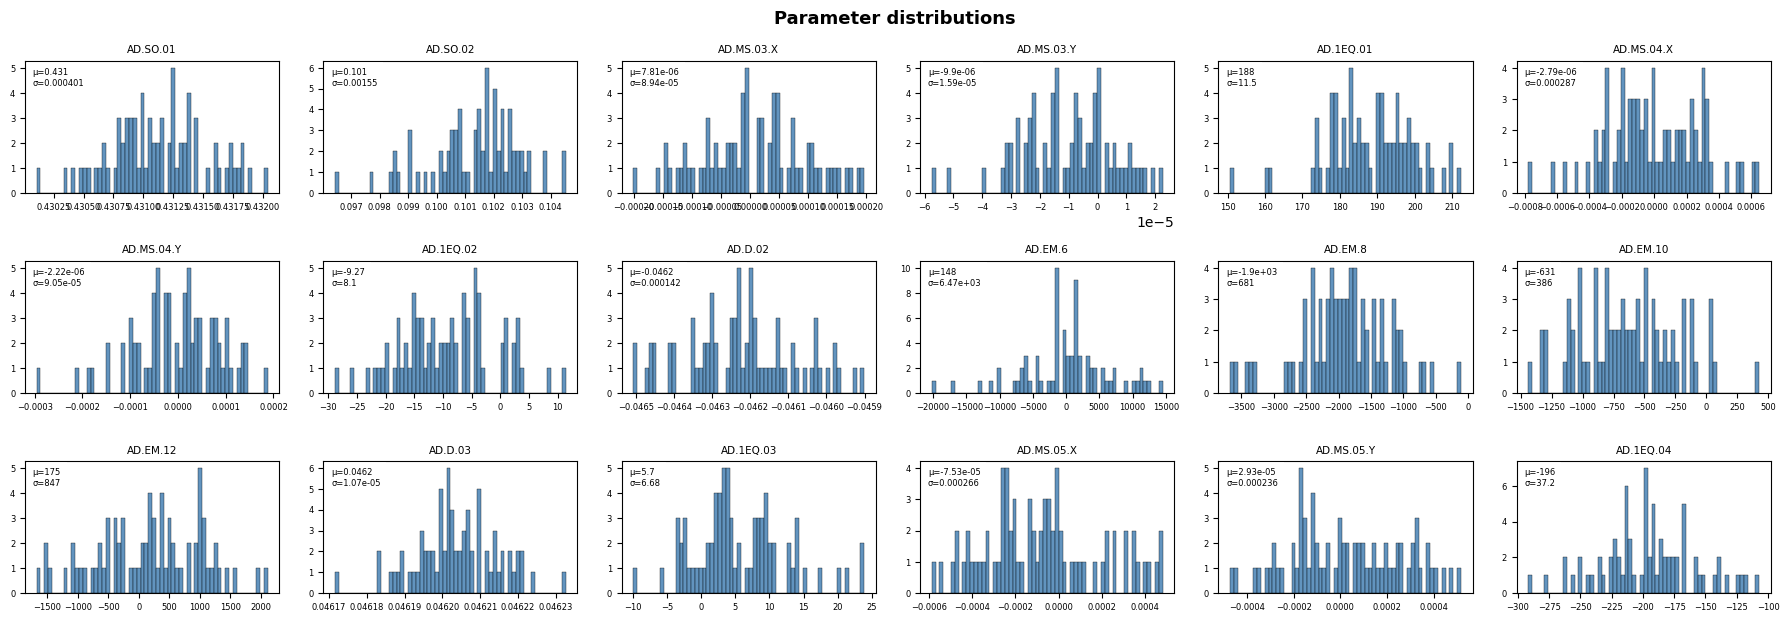

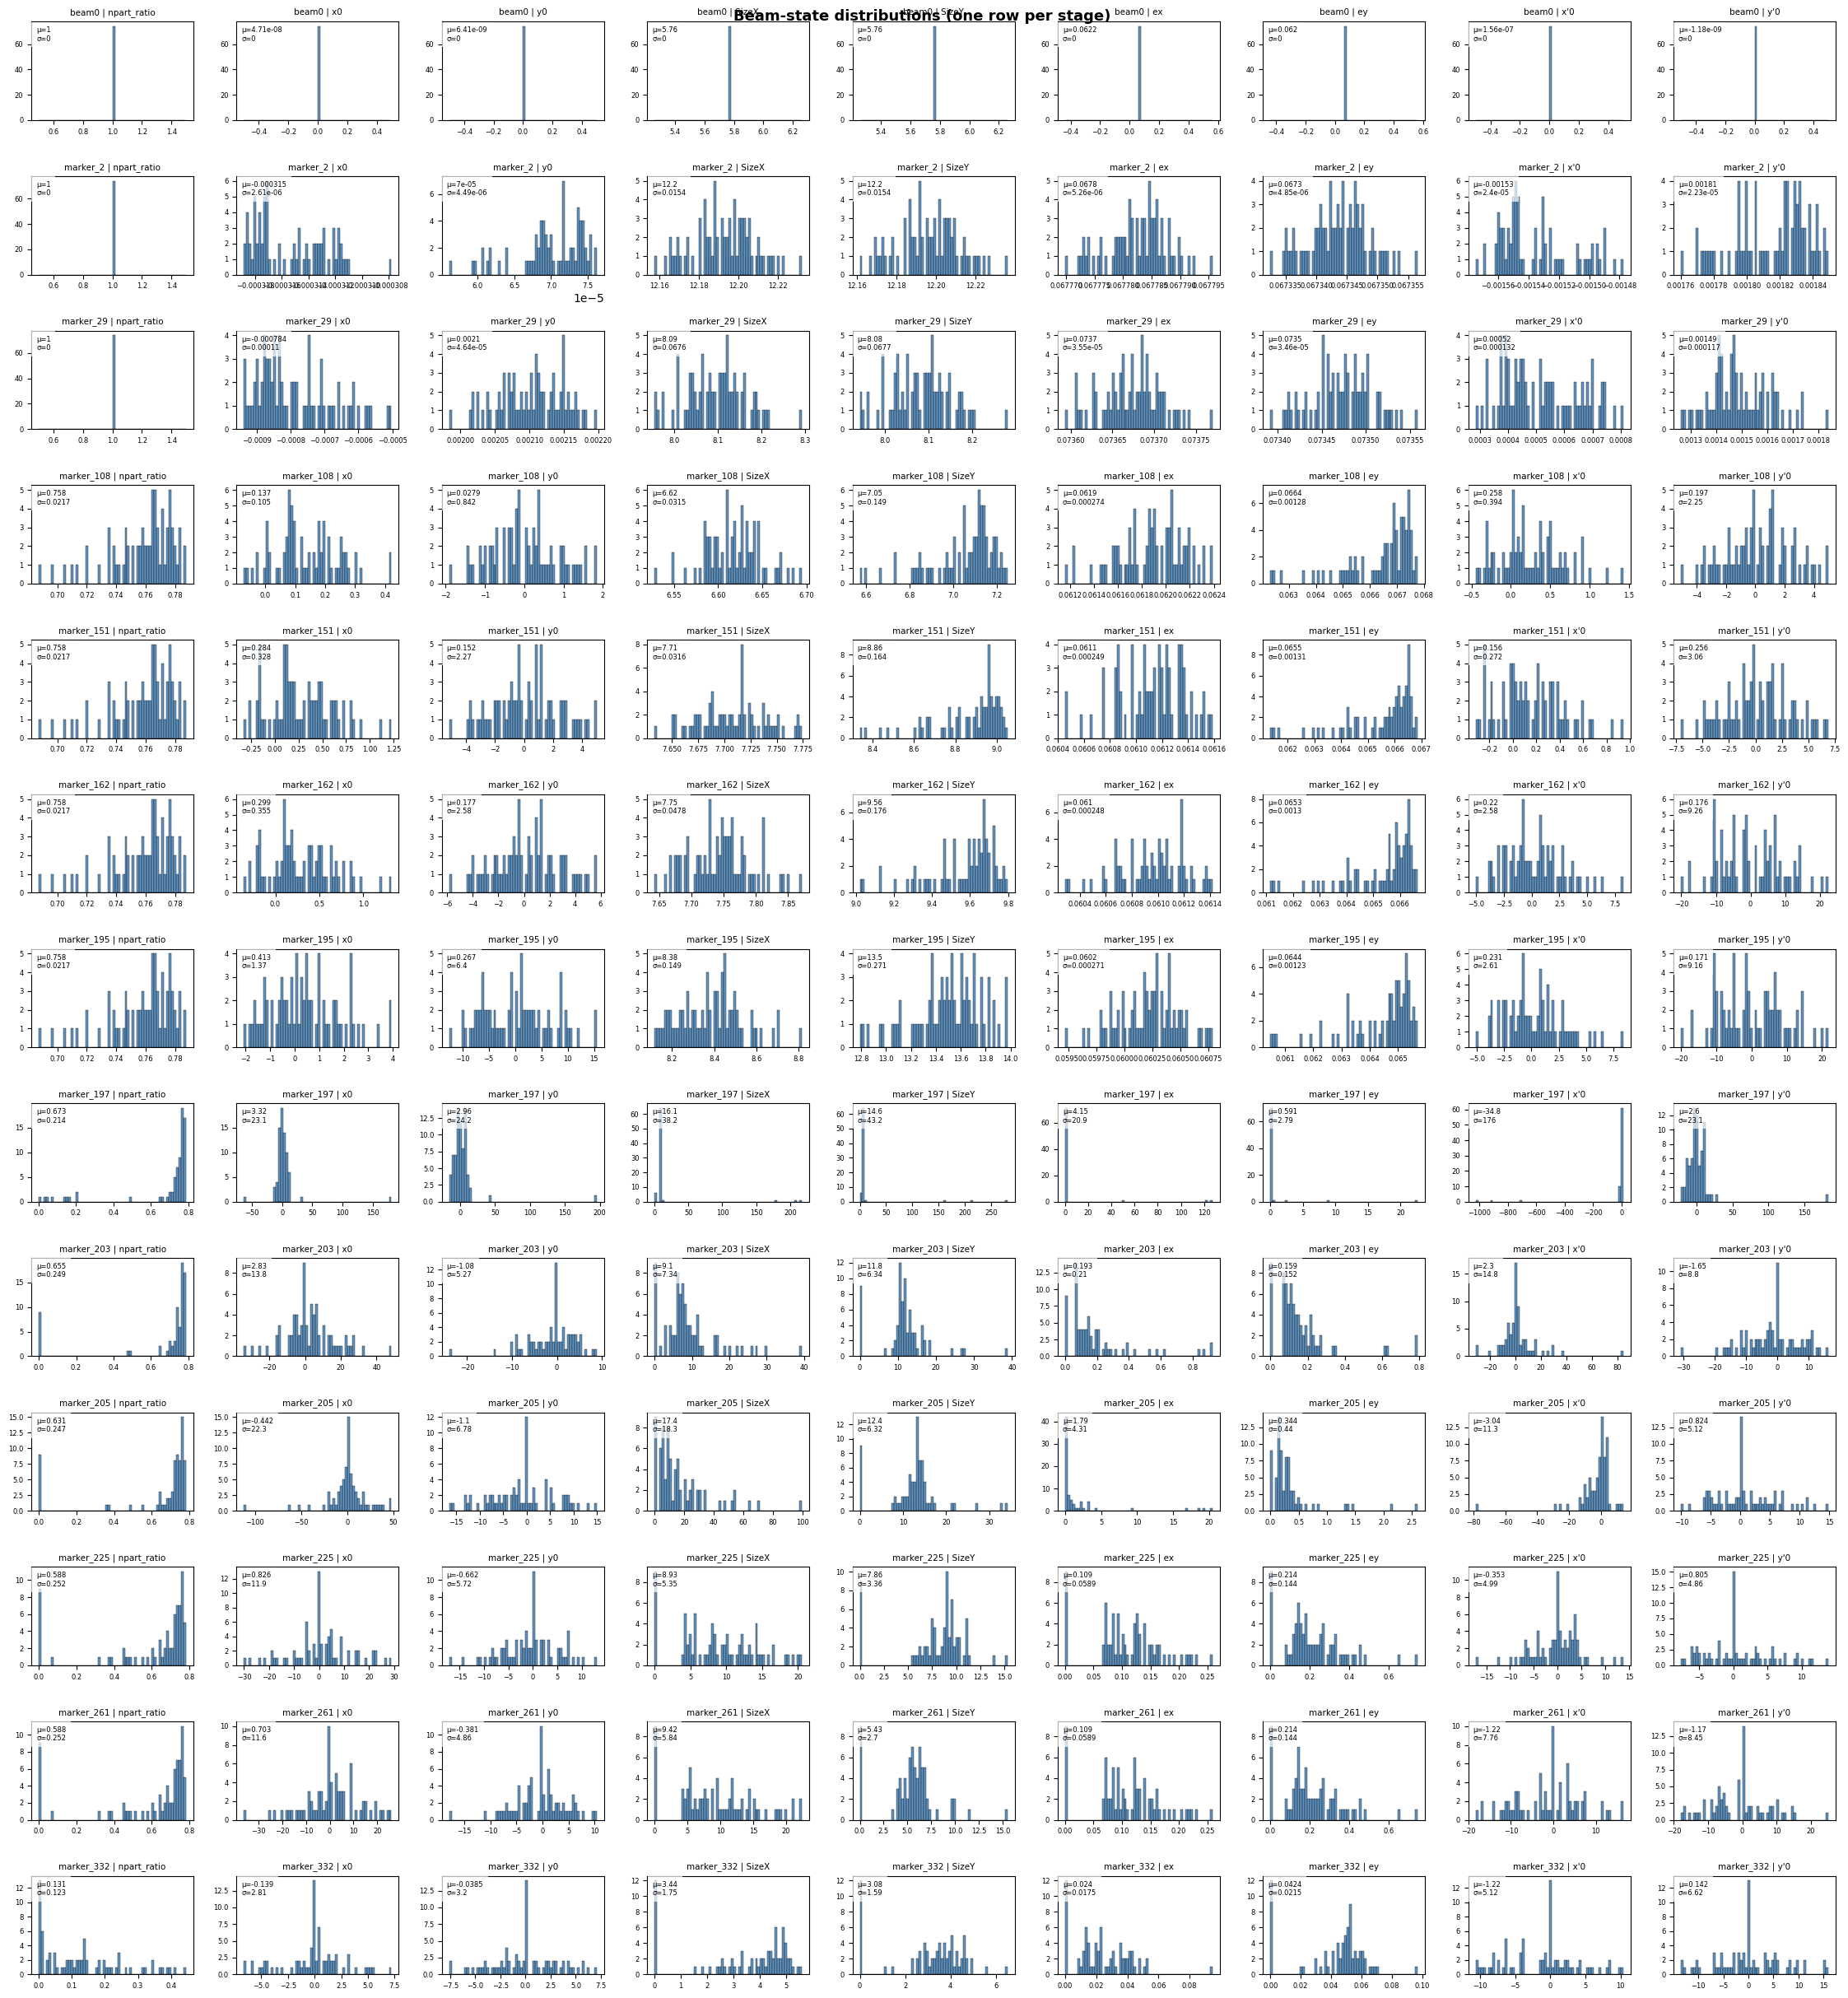

In [5]:
# --- Parameters ---
param_labels = [p.name for p in PARAMETERS]
plot_grid_hist(
    [param_vecs[:, i] for i in range(N_PARAMS)], param_labels,
    'Parameter distributions', ncols=6,
)

# --- Beam states: one grid row per stage (ncols = BEAM_STATE_DIM) ---
beam_labels = [f'{stage_label(s)} | {f}' for s in range(N_STAGES) for f in BEAM_STATE_FEATURES]
beam_data = [beam_stage_arrays[s][:, fi] for s in range(N_STAGES) for fi in range(BEAM_STATE_DIM)]
plot_grid_hist(
    beam_data, beam_labels, 'Beam-state distributions (one row per stage)',
    ncols=BEAM_STATE_DIM, cell_w=2.5, cell_h=1.9,
)

## 4. Score distribution

`DATASET_SCALE` is deliberately calibrated at an 80% (not 100%) success rate (see `exploration_scale_calculation`), so seeing a real fraction of `ERROR_SCORE` ("all particles lost") samples here is by design, not a bug -- it is exactly the ~20% of failure/near-boundary coverage the surrogate is meant to learn from.

Samples: 74
ERROR_SCORE (-999, all particles lost): 12 (16.2%)
Valid (non-error) scores: 62 (83.8%)
  min=-24.6807  max=33.7487  mean=2.07431  std=14.4909
  P05 = -19.4024
  P50 = 0.804207
  P95 = 28.1438


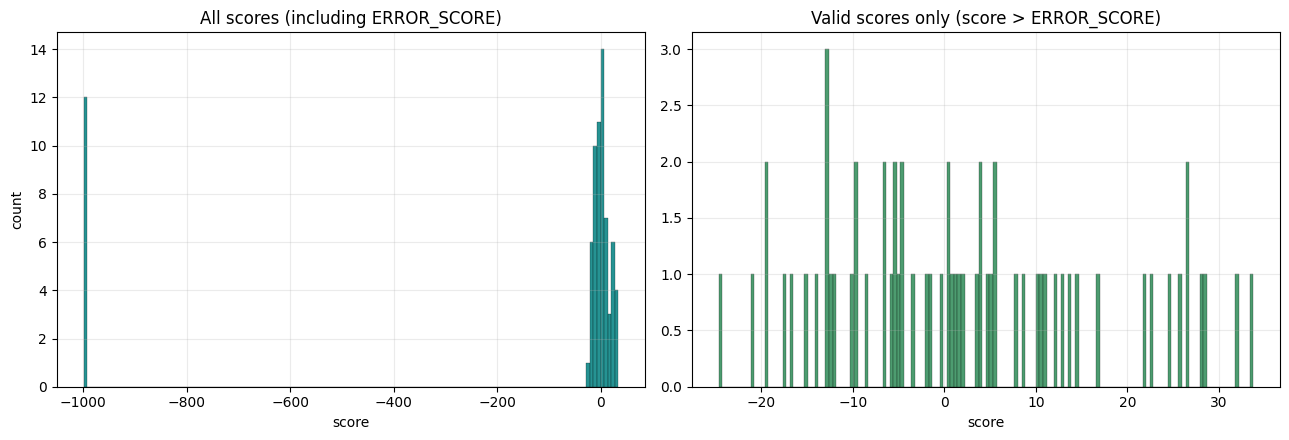

In [6]:
error_mask = scores <= ERROR_SCORE  # sentinel for "all particles lost" (score() clamps to exactly ERROR_SCORE)
n_error = int(error_mask.sum())
valid_scores = scores[~error_mask]

print(f'Samples: {n_samples}')
print(f'ERROR_SCORE ({fmt(ERROR_SCORE)}, all particles lost): {n_error} ({n_error / n_samples:.1%})')
print(f'Valid (non-error) scores: {len(valid_scores)} ({len(valid_scores) / n_samples:.1%})')
if len(valid_scores):
    print(f'  min={fmt(valid_scores.min())}  max={fmt(valid_scores.max())}  '
          f'mean={fmt(valid_scores.mean())}  std={fmt(valid_scores.std())}')
    for p in (5, 50, 95):
        print(f'  P{p:02d} = {fmt(np.percentile(valid_scores, p))}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(scores, bins=150, color='teal', alpha=0.85, edgecolor='black', linewidth=0.2)
axes[0].set_title('All scores (including ERROR_SCORE)')
axes[0].set_xlabel('score'); axes[0].set_ylabel('count'); axes[0].grid(alpha=0.25)
if len(valid_scores):
    axes[1].hist(valid_scores, bins=150, color='seagreen', alpha=0.85, edgecolor='black', linewidth=0.2)
axes[1].set_title('Valid scores only (score > ERROR_SCORE)')
axes[1].set_xlabel('score'); axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 5. Parameter <-> beam-state correlation

One combined Spearman correlation matrix: all `N_PARAMS` parameters (rows) against every beam-state feature at every stage (columns), computed in a single pass -- not one incremental heatmap per stage with a growing parameter subset.

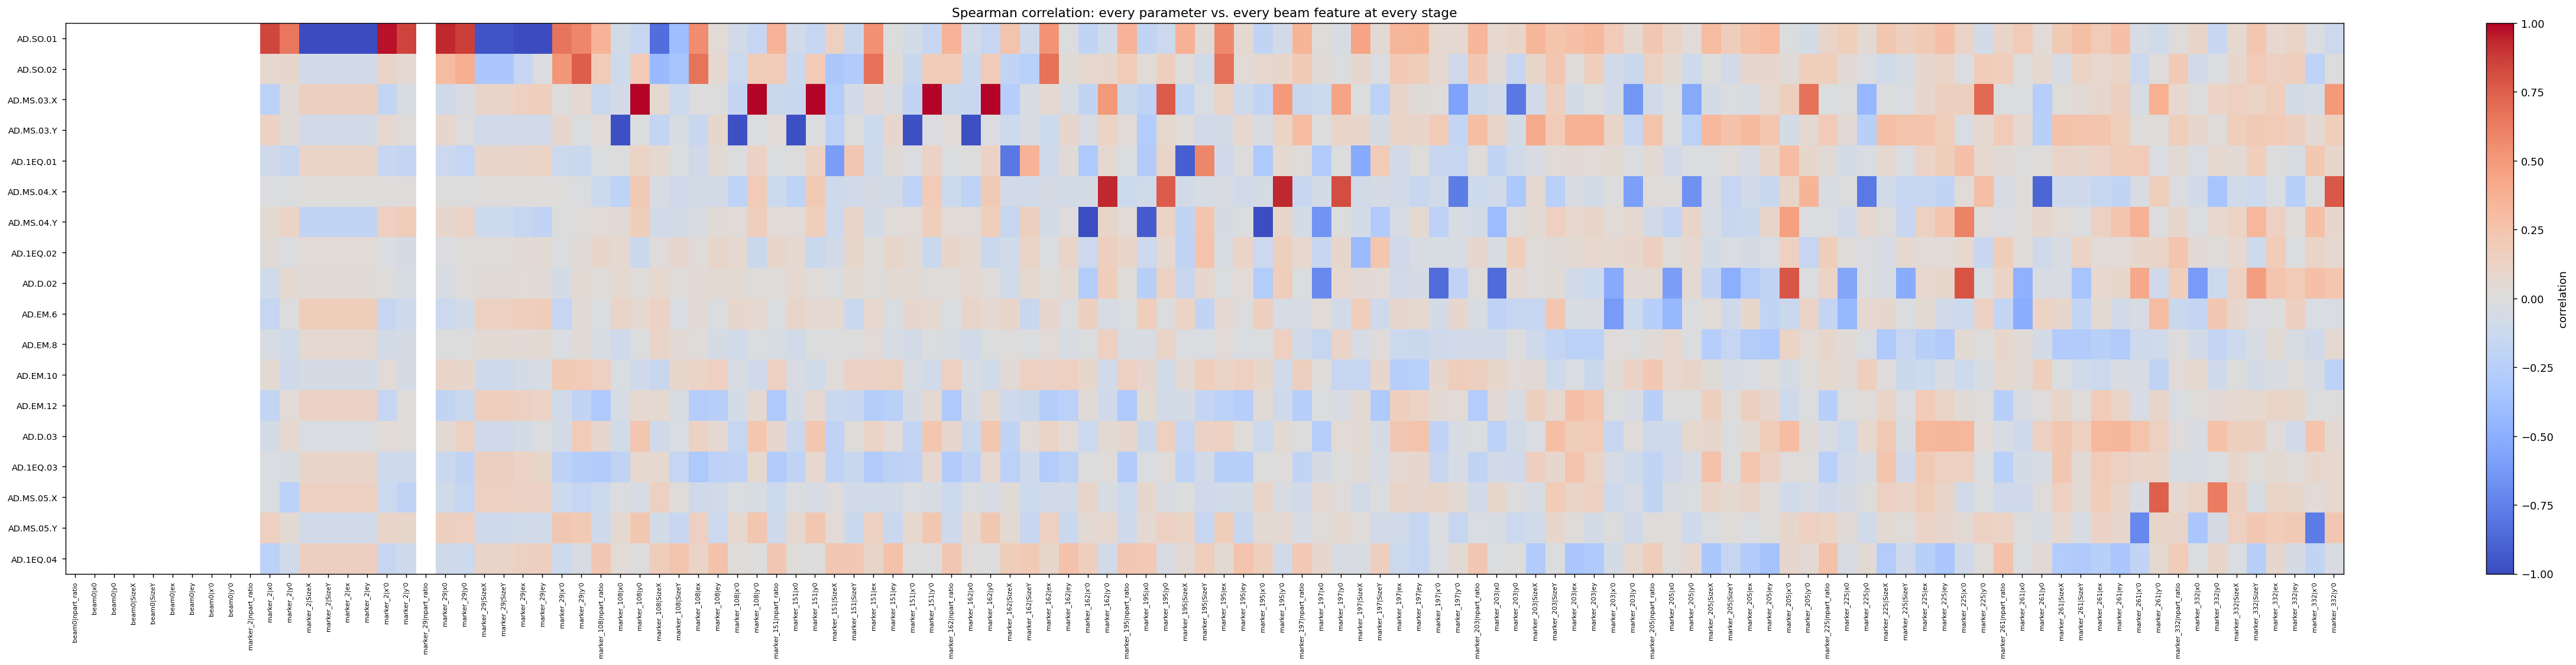

### Strongest parameter <-> beam-feature correlations (top 15 by |ρ|)

| Parameter | Beam feature | Spearman ρ |
| --- | --- | --- |
| AD.SO.01 | marker_2|SizeY | -1.000 |
| AD.SO.01 | marker_2|SizeX | -1.000 |
| AD.SO.01 | marker_2|ey | -1.000 |
| AD.SO.01 | marker_2|ex | -1.000 |
| AD.MS.03.X | marker_151|y'0 | +1.000 |
| AD.MS.03.X | marker_108|y'0 | +1.000 |
| AD.MS.03.X | marker_162|y0 | +1.000 |
| AD.MS.03.X | marker_151|y0 | +1.000 |
| AD.MS.03.X | marker_108|y0 | +0.999 |
| AD.SO.01 | marker_29|ey | -0.997 |
| AD.SO.01 | marker_29|ex | -0.993 |
| AD.MS.04.Y | marker_162|x'0 | -0.992 |
| AD.MS.04.Y | marker_195|x'0 | -0.992 |
| AD.MS.03.Y | marker_108|x0 | -0.982 |
| AD.MS.03.Y | marker_151|x0 | -0.980 |

In [7]:
beam_names = [f'{stage_label(s)}|{f}' for s in range(N_STAGES) for f in BEAM_STATE_FEATURES]
beam_matrix = np.concatenate(beam_stage_arrays, axis=1)  # (N, N_STAGES * BEAM_STATE_DIM)

df_params = pd.DataFrame(param_vecs, columns=[p.name for p in PARAMETERS])
df_beam = pd.DataFrame(beam_matrix, columns=beam_names)
corr = pd.concat([df_params, df_beam], axis=1).corr(method='spearman').loc[df_params.columns, df_beam.columns]

fig, ax = plt.subplots(figsize=(0.30 * len(beam_names) + 3, 0.32 * len(df_params.columns) + 3), dpi=130)
im = ax.imshow(corr.values, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(beam_names)))
ax.set_xticklabels(beam_names, rotation=90, fontsize=6)
ax.set_yticks(range(len(df_params.columns)))
ax.set_yticklabels(df_params.columns, fontsize=8)
ax.set_title('Spearman correlation: every parameter vs. every beam feature at every stage')
fig.colorbar(im, ax=ax, label='correlation')
fig.tight_layout()
plt.show()

flat = corr.stack().reset_index()
flat.columns = ['parameter', 'beam_feature', 'spearman']
flat['abs_corr'] = flat['spearman'].abs()
top = flat.sort_values('abs_corr', ascending=False).head(15)
display(Markdown('### Strongest parameter <-> beam-feature correlations (top 15 by |ρ|)\n\n' + table(
    ['Parameter', 'Beam feature', 'Spearman ρ'],
    [[row.parameter, row.beam_feature, f'{row.spearman:+.3f}'] for row in top.itertuples()],
)))

## 6. Dataset coverage

### Why self mean-KNN distance, in *this* notebook specifically

`render()` (`base_beam_env.py`) already plots a KNN-distance panel for an RL episode's visited
parameters, using `BeamDataset.param_knn_distance()` to say how far the policy strayed from the
training data. Repeating that computation here, on the dataset against *itself*, is not redundant --
it serves two purposes that only make sense at the dataset level:

- **Reference baseline.** A raw number like `KNN=2.3` for one RL-episode step is meaningless on its
  own -- is that close or far? This section's median/P95, computed over points that genuinely *are*
  in the dataset, is exactly the "normal/typical" scale to compare that number against.
- **Dataset self-diagnosis.** Near-zero distances flag likely duplicate/near-duplicate samples (a
  builder bug or insufficient randomness); the extreme upper tail flags isolated outlier points the
  surrogate has essentially no real neighbors to learn from.

Two plots below: (left) self mean-KNN distance, in the same sensitivity-normalized units
`sensitivity_vec()` uses, via the real `dataset.param_knn_distance()` (not a reimplementation) --
small = densely-sampled region, large = isolated/sparse region; (right) a companion metric, RMS
deviation from `default_params()` in sensitivity units, with a `DATASET_SCALE` reference line -- a
direct sanity check that the dataset was actually generated at its intended calibrated width.

Self mean-KNN sensitivity-normalized distance (k=20, includes one self-match each):
  min=3.83843  max=6.14407  mean=4.68833  std=0.477589

RMS deviation from default_params(), in sensitivity units (target ~= DATASET_SCALE = 0.6):
  min=0.356351  max=0.831462  mean=0.589625  std=0.109744


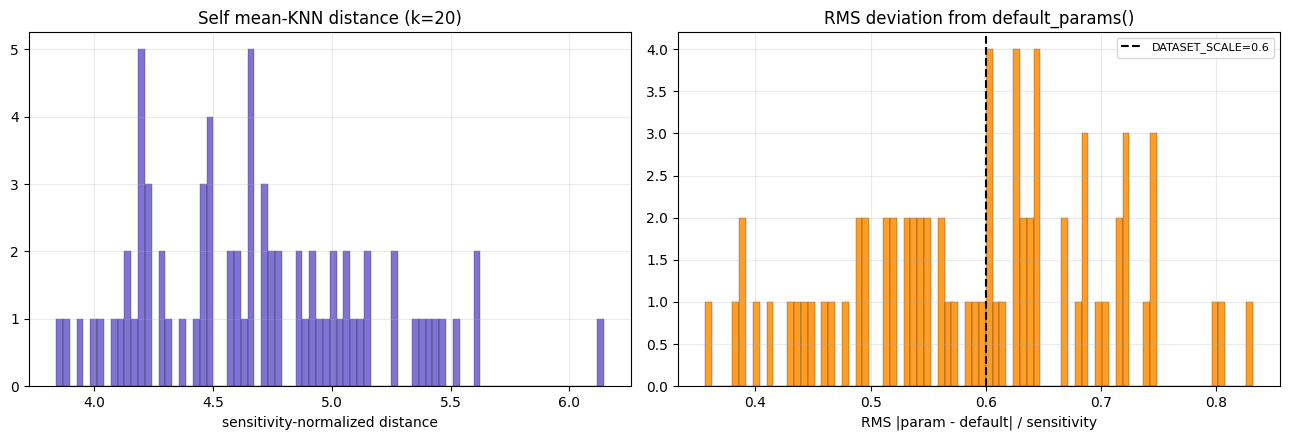

In [8]:
knn_k = min(20, max(2, n_samples - 1))
# +1 because every query point is itself a dataset point, so its own zero
# distance is always the nearest "neighbor" found; this shifts every value
# down by a uniform ~1/(k+1) fraction, it does not distort the relative
# spread across the dataset.
self_knn = dataset.param_knn_distance(param_vecs, k=knn_k + 1)

print(f'Self mean-KNN sensitivity-normalized distance (k={knn_k}, includes one self-match each):')
print(f'  min={fmt(self_knn.min())}  max={fmt(self_knn.max())}  mean={fmt(self_knn.mean())}  std={fmt(self_knn.std())}')

default_vec = params_to_vec(default_params())
normalized_dev = (param_vecs - default_vec) / sens          # (N, N_PARAMS), in sensitivity units
radius = np.sqrt((normalized_dev ** 2).mean(axis=1))          # RMS per-parameter deviation, comparable to DATASET_SCALE

print(f'\nRMS deviation from default_params(), in sensitivity units (target ~= DATASET_SCALE = {fmt(DATASET_SCALE)}):')
print(f'  min={fmt(radius.min())}  max={fmt(radius.max())}  mean={fmt(radius.mean())}  std={fmt(radius.std())}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(self_knn, bins=80, color='slateblue', alpha=0.85, edgecolor='black', linewidth=0.2)
axes[0].set_title(f'Self mean-KNN distance (k={knn_k})')
axes[0].set_xlabel('sensitivity-normalized distance'); axes[0].grid(alpha=0.25)

axes[1].hist(radius, bins=80, color='darkorange', alpha=0.85, edgecolor='black', linewidth=0.2)
axes[1].axvline(DATASET_SCALE, color='black', linestyle='--', label=f'DATASET_SCALE={fmt(DATASET_SCALE)}')
axes[1].set_title('RMS deviation from default_params()')
axes[1].set_xlabel('RMS |param - default| / sensitivity'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()